<a href="https://colab.research.google.com/github/habibiputrar/Habibi-Putra-Rizqullah_2411531001_ML2526/blob/main/Mini%20Project/Boosting_voting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRAKTIKUM 10
## Topik: Boosting, Voting & Mini Project

| | |
|---|---|
| **Nama** | Habibi Putra Rizqullah |
| **NIM** | 2411531001 |
| **Kelas** | B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Dr. Derisma |


---
## 3.1 Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier, GradientBoostingClassifier,
    RandomForestClassifier, VotingClassifier
)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("✅ Library berhasil diimport")

✅ Library berhasil diimport


---
## 3.2 Load & Split Data

In [3]:
url = "https://raw.githubusercontent.com/habibiputrar/Habibi-Putra-Rizqullah_2411531001_ML2526/refs/heads/main/Praktikum6/breast-cancer.csv"

df = pd.read_csv(url)
print("Shape:", df.shape)
print("\nInfo Dataset:")
print(df.head())

Shape: (569, 32)

Info Dataset:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_

In [4]:
# Drop kolom id yang tidak relevan
df = df.drop(columns=['id'], errors='ignore')

# Encode label: M=1 (Malignant), B=0 (Benign)
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])  # M=1, B=0

# Pisahkan fitur dan target
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

print("Distribusi kelas:")
print(y.value_counts())
print(f"\nTotal fitur: {X.shape[1]}")
print(f"Total sampel: {X.shape[0]}")

Distribusi kelas:
diagnosis
0    357
1    212
Name: count, dtype: int64

Total fitur: 30
Total sampel: 569


In [5]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train_scaled.shape}")
print(f"Test size : {X_test_scaled.shape}")

Train size: (455, 30)
Test size : (114, 30)


---
## 🔹 Bagian A.  Boosting
### 3.3 AdaBoost

In [6]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=42
)
ada.fit(X_train_scaled, y_train)

acc_ada = accuracy_score(y_test, ada.predict(X_test_scaled))
cv_ada = cross_val_score(ada, X_train_scaled, y_train, cv=5).mean()

print(f"AdaBoost Accuracy  : {acc_ada:.4f}")
print(f"AdaBoost CV Score  : {cv_ada:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, ada.predict(X_test_scaled), target_names=['Benign', 'Malignant']))

AdaBoost Accuracy  : 0.9737
AdaBoost CV Score  : 0.9604

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



### 3.4 Gradient Boosting

In [7]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, y_train)

acc_gb = accuracy_score(y_test, gb.predict(X_test_scaled))
cv_gb = cross_val_score(gb, X_train_scaled, y_train, cv=5).mean()

print(f"Gradient Boosting Accuracy : {acc_gb:.4f}")
print(f"Gradient Boosting CV Score : {cv_gb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, gb.predict(X_test_scaled), target_names=['Benign', 'Malignant']))

Gradient Boosting Accuracy : 0.9649
Gradient Boosting CV Score : 0.9538

Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



---
## 🔹 Bagian B. Voting Classifier
### 3.5 Soft Voting

In [8]:
log = LogisticRegression(max_iter=5000, random_state=42)
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
gb2 = GradientBoostingClassifier(n_estimators=100, random_state=42)

voting_soft = VotingClassifier(
    estimators=[('log', log), ('rf', rf), ('gb', gb2)],
    voting='soft'
)
voting_soft.fit(X_train_scaled, y_train)

acc_vote = accuracy_score(y_test, voting_soft.predict(X_test_scaled))
cv_vote  = cross_val_score(voting_soft, X_train_scaled, y_train, cv=5).mean()

print(f"Voting (Soft) Accuracy : {acc_vote:.4f}")
print(f"Voting (Soft) CV Score : {cv_vote:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, voting_soft.predict(X_test_scaled), target_names=['Benign', 'Malignant']))

Voting (Soft) Accuracy : 0.9649
Voting (Soft) CV Score : 0.9670

Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



---
## 🔹 Bagian C. Hyperparameter Tuning
### 3.6 GridSearchCV (Random Forest)

In [9]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [None, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

best_rf = grid.best_estimator_
acc_best_rf = accuracy_score(y_test, best_rf.predict(X_test_scaled))

print(f"Best Parameters : {grid.best_params_}")
print(f"Best CV Score   : {grid.best_score_:.4f}")
print(f"Test Accuracy   : {acc_best_rf:.4f}")

Best Parameters : {'max_depth': None, 'n_estimators': 50}
Best CV Score   : 0.9670
Test Accuracy   : 0.9737


---
## 🔹 Bagian D. PCA + Ensemble
### 3.7 PCA + Gradient Boosting

Variance explained (10 komponen): 0.9521


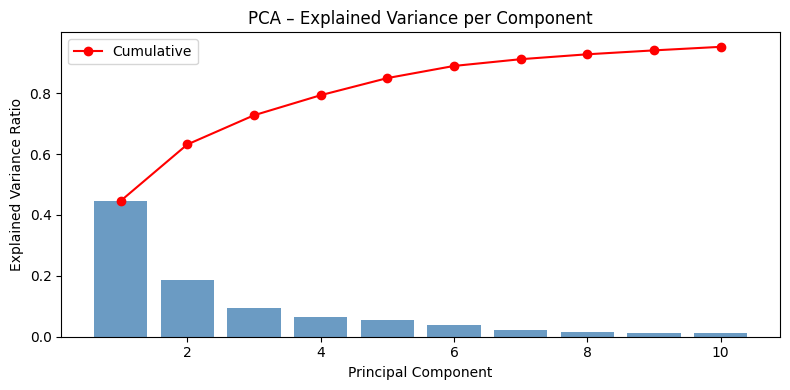

In [10]:
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"Variance explained (10 komponen): {pca.explained_variance_ratio_.sum():.4f}")

# Visualisasi explained variance
plt.figure(figsize=(8, 4))
plt.bar(range(1, 11), pca.explained_variance_ratio_, color='steelblue', alpha=0.8)
plt.plot(range(1, 11), np.cumsum(pca.explained_variance_ratio_), 'ro-', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA – Explained Variance per Component')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
gb_pca = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_pca.fit(X_train_pca, y_train)

acc_gb_pca = accuracy_score(y_test, gb_pca.predict(X_test_pca))
cv_gb_pca  = cross_val_score(gb_pca, X_train_pca, y_train, cv=5).mean()

print(f"Gradient Boosting + PCA Accuracy : {acc_gb_pca:.4f}")
print(f"Gradient Boosting + PCA CV Score : {cv_gb_pca:.4f}")

Gradient Boosting + PCA Accuracy : 0.9561
Gradient Boosting + PCA CV Score : 0.9429


---
## 🔹 Bagian E. Tabel Perbandingan Akhir

In [13]:
# Tambahan: Logistic Regression baseline
lr_base = LogisticRegression(max_iter=5000, random_state=42)
lr_base.fit(X_train_scaled, y_train)
acc_lr = accuracy_score(y_test, lr_base.predict(X_test_scaled))
cv_lr  = cross_val_score(lr_base, X_train_scaled, y_train, cv=5).mean()

# Tambahan: Random Forest baseline
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train_scaled, y_train)
acc_rf = accuracy_score(y_test, rf_base.predict(X_test_scaled))
cv_rf  = cross_val_score(rf_base, X_train_scaled, y_train, cv=5).mean()

results = {
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'AdaBoost',
        'Gradient Boosting',
        'Voting (Soft)',
        'Best Tuned RF',
        'Gradient Boosting + PCA'
    ],
    'Test Accuracy': [
        round(acc_lr, 4),
        round(acc_rf, 4),
        round(acc_ada, 4),
        round(acc_gb, 4),
        round(acc_vote, 4),
        round(acc_best_rf, 4),
        round(acc_gb_pca, 4)
    ],
    'CV Score (5-fold)': [
        round(cv_lr, 4),
        round(cv_rf, 4),
        round(cv_ada, 4),
        round(cv_gb, 4),
        round(cv_vote, 4),
        round(grid.best_score_, 4),
        round(cv_gb_pca, 4)
    ]
}

df_results = pd.DataFrame(results)
df_results = df_results.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print(df_results.to_string(index=False))

                  Model  Test Accuracy  CV Score (5-fold)
          Random Forest         0.9737             0.9626
               AdaBoost         0.9737             0.9604
          Best Tuned RF         0.9737             0.9670
    Logistic Regression         0.9649             0.9714
      Gradient Boosting         0.9649             0.9538
          Voting (Soft)         0.9649             0.9670
Gradient Boosting + PCA         0.9561             0.9429


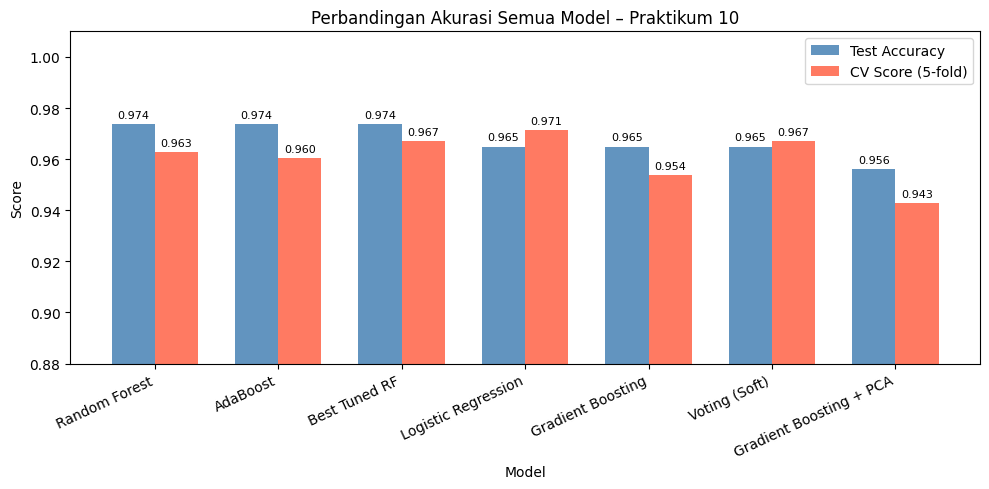

In [14]:
# Visualisasi perbandingan model
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(df_results))
width = 0.35

bars1 = ax.bar(x - width/2, df_results['Test Accuracy'], width, label='Test Accuracy', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, df_results['CV Score (5-fold)'], width, label='CV Score (5-fold)', color='tomato', alpha=0.85)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Perbandingan Akurasi Semua Model – Praktikum 10')
ax.set_xticks(x)
ax.set_xticklabels(df_results['Model'], rotation=25, ha='right')
ax.set_ylim(0.88, 1.01)
ax.legend()

# Anotasi nilai
for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()